# IAA Laboratori 10 - Itemsets - Apriori

## Affinity analysis

Affinity analysis is a data analysis and data mining technique that discovers co-occurrence relationships among activities performed by (or recorded about) specific individuals or groups. In general, this can be applied to any process where agents can be uniquely identified and information about their activities can be recorded. In retail, affinity analysis is used to perform market basket analysis, in which retailers seek to understand the purchase behavior of customers.

## Setting up the environment

In [ ]:
#%pip install mlxtend bokeh squarify 
#%pip install PyARMViz
#%pip install nltk
#%pip install wordcloud


In [302]:
## Data processing
import pandas as pd
import numpy as np

## Item processing
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

## Graph support
import networkx as nx 

## Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot
import matplotlib
import matplotlib.pyplot as plt
import squarify
from matplotlib import style
import seaborn as sns
from PyARMViz import PyARMViz
from PyARMViz.Rule import generate_rule_from_dict

# Hiding warnings 
import warnings

In [303]:
# Display images and HTML datatables
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import display, HTML
show_html = lambda html: display(HTML(html))

# Time
from time import time
from datetime import timedelta
init_time = time()

## Visualization
#%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (16, 10)
style.use('ggplot')
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set()

# Hiding warnings 
warnings.filterwarnings("ignore")

## Apriori algorithm

Apriori is a popular algorithm [1] for extracting frequent itemsets with applications in association rule learning. The apriori algorithm has been designed to operate on databases containing transactions, such as purchases by customers of a store. An itemset is considered as "frequent" if it meets a user-specified support threshold. For instance, if the support threshold is set to 0.5 (50%), a frequent itemset is defined as a set of items that occur together in at least 50% of all transactions in the database.

Apriori is an algorithm for frequent itemset mining and association rule learning over relational databases. It proceeds by identifying the frequent individual items in the database and extending them to larger and larger item sets as long as those item sets appear sufficiently often in the database. The frequent itemsets determined by Apriori can be used to determine association rules which highlight general trends in the database: this has applications in domains such as market basket analysis.

> **Support**: This says how popular an itemset is, as measured by the proportion of transactions in which an itemset appears.

> **Confidence**: This says how likely item Y is purchased when item X is purchased, expressed as {X -> Y}. This is measured by the proportion of transactions with item X, in which item Y also appears.

> **Lift**: This says how likely item Y is purchased when item X is purchased while controlling for how popular item Y is.

Apriori uses a "bottom up" approach, where frequent subsets are extended one item at a time (a step known as candidate generation), and groups of candidates are tested against the data. The algorithm terminates when no further successful extensions are found.

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/549fa6a5f46897d137b5d704ef7f30b6ba36d4de)

[1] Tan, Steinbach, Kumar. Introduction to Data Mining. Pearson New International Edition. Harlow: Pearson Education Ltd., 2014. (pp. 327-414).

### Generating Frequent Itemsets

The `apriori` function expects data in a one-hot encoded pandas DataFrame.
Suppose we have the following transaction data:

In [391]:
dataset = [['Milk', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Dill', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Milk', 'Apple', 'Kidney Beans', 'Eggs'],
           ['Milk', 'Unicorn', 'Corn', 'Kidney Beans', 'Yogurt'],
           ['Corn', 'Onion', 'Onion', 'Kidney Beans', 'Ice cream', 'Eggs']]

dataset

[['Milk', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
 ['Dill', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
 ['Milk', 'Apple', 'Kidney Beans', 'Eggs'],
 ['Milk', 'Unicorn', 'Corn', 'Kidney Beans', 'Yogurt'],
 ['Corn', 'Onion', 'Onion', 'Kidney Beans', 'Ice cream', 'Eggs']]

We can transform it into the right format via the `TransactionEncoder` as follows:

In [392]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)
df

,Apple,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Unicorn,Yogurt
0,False,False,False,True,False,True,True,True,True,False,True
1,False,False,True,True,False,True,False,True,True,False,True
2,True,False,False,True,False,True,True,False,False,False,False
3,False,True,False,False,False,True,True,False,False,True,True
4,False,True,False,True,True,True,False,False,True,False,False


Lets consider the rule X => Y in order to compute these metrics.

![](https://s3.ap-south-1.amazonaws.com/techleer/243.jpg)

Now, let us return the items and itemsets with at least 60% support:

In [393]:
from mlxtend.frequent_patterns import apriori

apriori(df, min_support=0.6)

,support,itemsets
0,0.800,(3)
1,1.000,(5)
2,0.600,(6)
3,0.600,(8)
4,0.600,(10)
5,0.800,"(3, 5)"
6,0.600,"(8, 3)"
7,0.600,"(5, 6)"
8,0.600,"(8, 5)"
9,0.600,"(10, 5)"


By default, `apriori` returns the column indices of the items, which may be useful in downstream operations such as association rule mining. For better readability, we can set `use_colnames=True` to convert these integer values into the respective item names: 

In [394]:
apriori(df, min_support=0.6, use_colnames=True)

,support,itemsets
0,0.800,(Eggs)
1,1.000,(Kidney Beans)
2,0.600,(Milk)
3,0.600,(Onion)
4,0.600,(Yogurt)
5,0.800,"(Eggs, Kidney Beans)"
6,0.600,"(Eggs, Onion)"
7,0.600,"(Kidney Beans, Milk)"
8,0.600,"(Onion, Kidney Beans)"
9,0.600,"(Yogurt, Kidney Beans)"


### Selecting and Filtering Results

The advantage of working with pandas `DataFrames` is that we can use its convenient features to filter the results. For instance, let's assume we are only interested in itemsets of length 2 that have a support of at least 80 percent. First, we create the frequent itemsets via `apriori` and add a new column that stores the length of each itemset:

In [395]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df, min_support=0.6, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets

,support,itemsets,length
0,0.800,(Eggs),1
1,1.000,(Kidney Beans),1
2,0.600,(Milk),1
3,0.600,(Onion),1
4,0.600,(Yogurt),1
5,0.800,"(Eggs, Kidney Beans)",2
6,0.600,"(Eggs, Onion)",2
7,0.600,"(Kidney Beans, Milk)",2
8,0.600,"(Onion, Kidney Beans)",2
9,0.600,"(Yogurt, Kidney Beans)",2


Then, we can select the results that satisfy our desired criteria as follows:

In [396]:
frequent_itemsets[ (frequent_itemsets['length'] == 2) &
                   (frequent_itemsets['support'] >= 0.8) ]

,support,itemsets,length
5,0.800,"(Eggs, Kidney Beans)",2


Similarly, using the Pandas API, we can select entries based on the "itemsets" column:

In [397]:
frequent_itemsets[ frequent_itemsets['itemsets'] == {'Onion', 'Eggs'} ]

,support,itemsets,length
6,0.600,"(Eggs, Onion)",2


**Frozensets**

Note that the entries in the "itemsets" column are of type `frozenset`, which is built-in Python type that is similar to a Python `set` but immutable, which makes it more efficient for certain query or comparison operations (https://docs.python.org/3.6/library/stdtypes.html#frozenset). Since `frozenset`s are sets, the item order does not matter. I.e., the query

`frequent_itemsets[ frequent_itemsets['itemsets'] == {'Onion', 'Eggs'} ]`
    
is equivalent to any of the following three

- `frequent_itemsets[ frequent_itemsets['itemsets'] == {'Eggs', 'Onion'} ]`
- `frequent_itemsets[ frequent_itemsets['itemsets'] == frozenset(('Eggs', 'Onion')) ]`
- `frequent_itemsets[ frequent_itemsets['itemsets'] == frozenset(('Onion', 'Eggs')) ]`

### Working with Sparse Representations

To save memory, you may want to represent your transaction data in the sparse format.
This is especially useful if you have lots of products and small transactions.

In [398]:
oht_ary = te.fit(dataset).transform(dataset, sparse=True)
sparse_df = pd.DataFrame.sparse.from_spmatrix(oht_ary, columns=te.columns_)
sparse_df

,Apple,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Unicorn,Yogurt
0,0,0,0,1,0,True,1,1,1,0,1
1,0,0,1,1,0,True,0,1,1,0,1
2,1,0,0,1,0,True,1,0,0,0,0
3,0,1,0,0,0,True,1,0,0,1,1
4,0,1,0,1,1,True,0,0,1,0,0


In [399]:
apriori(sparse_df, min_support=0.6, use_colnames=True, verbose=1)

Processing 21 combinations | Sampling itemset size 3


,support,itemsets
0,0.800,(Eggs)
1,1.000,(Kidney Beans)
2,0.600,(Milk)
3,0.600,(Onion)
4,0.600,(Yogurt)
5,0.800,"(Eggs, Kidney Beans)"
6,0.600,"(Eggs, Onion)"
7,0.600,"(Kidney Beans, Milk)"
8,0.600,"(Onion, Kidney Beans)"
9,0.600,"(Yogurt, Kidney Beans)"


In [400]:
apriori(df, min_support=0.6, use_colnames=True, verbose=1)

Processing 21 combinations | Sampling itemset size 3


,support,itemsets
0,0.800,(Eggs)
1,1.000,(Kidney Beans)
2,0.600,(Milk)
3,0.600,(Onion)
4,0.600,(Yogurt)
5,0.800,"(Eggs, Kidney Beans)"
6,0.600,"(Eggs, Onion)"
7,0.600,"(Kidney Beans, Milk)"
8,0.600,"(Onion, Kidney Beans)"
9,0.600,"(Yogurt, Kidney Beans)"


PLAYTIME
<div class="alert alert-success">
PLAYTIME: How support affects the size of the frequent itemsets? what does a user mean by selecting a support value of 0.2? 
</div>

## Association rules generation from frequent itemsets

The apriori() generates the most relevent set of rules from a given transaction data. It also shows the support, confidence and lift of those rules. These three measure can be used to decide the relative strength of the rules. So what do these terms mean?


Rule generation is a common task in the mining of frequent patterns. _An association rule is an implication expression of the form $X \rightarrow Y$, where $X$ and $Y$ are disjoint itemsets_ [1]. A more concrete example based on consumer behaviour would be  $\{Diapers\} \rightarrow \{Beer\}$ suggesting that people who buy diapers are also likely to buy beer. To evaluate the "interest" of such an association rule, different metrics have been developed. The current implementation make use of the `confidence` and `lift` metrics. 


### Metrics

The currently supported metrics for evaluating association rules and setting selection thresholds are listed below. Given a rule "A -> C", *A* stands for antecedent and *C* stands for consequent.


#### 'support':

$$\text{support}(A\rightarrow C) = \text{support}(A \cup C), \;\;\; \text{range: } [0, 1]$$

- introduced in [3]

The support metric is defined for itemsets, not assocication rules. The table produced by the association rule mining algorithm contains three different support metrics: 'antecedent support', 'consequent support', and 'support'. Here, 'antecedent support' computes the proportion of transactions that contain the antecedent A, and 'consequent support' computes the support for the itemset of the consequent C. The 'support' metric then computes the support of the combined itemset A $\cup$ C.


Typically, support is used to measure the abundance or frequency (often interpreted as significance or importance) of an itemset in a database. We refer to an itemset as a "frequent itemset" if you support is larger than a specified minimum-support threshold. Note that in general, due to the *downward closure* property, all subsets of a frequent itemset are also frequent.


#### 'confidence':  

$$\text{confidence}(A\rightarrow C) = \frac{\text{support}(A\rightarrow C)}{\text{support}(A)}, \;\;\; \text{range: } [0, 1]$$

- introduced in [3]

The confidence of a rule A->C is the probability of seeing the consequent in a transaction given that it also contains the antecedent. Note that the metric is not symmetric or directed; for instance, the confidence for A->C is different than the confidence for C->A. The confidence is 1 (maximal) for a rule A->C if the consequent and antecedent always occur together. 


#### 'lift':

$$\text{lift}(A\rightarrow C) = \frac{\text{confidence}(A\rightarrow C)}{\text{support}(C)}, \;\;\; \text{range: } [0, \infty]$$


- introduced in [4]


The lift metric is commonly used to measure how much more often the antecedent and consequent of a rule A->C occur together than we would expect if they were statistically independent. If A and C are independent, the Lift score will be exactly 1.


#### 'leverage':

$$\text{levarage}(A\rightarrow C) = \text{support}(A\rightarrow C) - \text{support}(A) \times \text{support}(C), \;\;\; \text{range: } [-1, 1]$$


- introduced in [5]

Leverage computes the difference between the observed frequency of A and C appearing together and the frequency that would be expected if A and C were independent. A leverage value of 0 indicates independence.

#### 'conviction':

$$\text{conviction}(A\rightarrow C) = \frac{1 - \text{support}(C)}{1 - \text{confidence}(A\rightarrow C)}, \;\;\; \text{range: } [0, \infty]$$

- introduced in [6]

A high conviction value means that the consequent is highly depending on the antecedent. For instance, in the case of a perfect confidence score, the denominator becomes 0 (due to 1 - 1) for which the conviction score is defined as 'inf'. Similar to lift, if items are independent, the conviction is 1.

#### 'zhangs_metric':

$$\text{zhangs metric}(A\rightarrow C) = \frac{\text{confidence}(A\rightarrow C) - \text{confidence}(A'\rightarrow C)}{Max[ \text{confidence}(A\rightarrow C) , \text{confidence}(A'\rightarrow C)]}, \;\;\; \text{range: } [-1, 1]$$

- introduced in [7]

Measures both association and dissociation. Value ranges between -1 and 1. A positive value (>0) indicates Association and negative value indicated dissociation.


[1] Tan, Steinbach, Kumar. Introduction to Data Mining. Pearson New International Edition. Harlow: Pearson Education Ltd., 2014. (pp. 327-414).

[2] Michael Hahsler, https://michael.hahsler.net/research/association_rules/measures.html

[3] R. Agrawal, T. Imielinski, and A. Swami. Mining associations between sets of items in large databases. In Proc. of the ACM SIGMOD Int'l Conference on Management of Data, pages 207-216, Washington D.C., May 1993

[4] S. Brin, R. Motwani, J. D. Ullman, and S. Tsur. Dynamic itemset counting and implication rules for market basket data

[5]  Piatetsky-Shapiro, G., Discovery, analysis, and presentation of strong rules. Knowledge Discovery in Databases, 1991: p. 229-248.

[6] Sergey Brin, Rajeev Motwani, Jeffrey D. Ullman, and Shalom Turk. Dynamic itemset counting and implication rules for market basket data. In SIGMOD 1997, Proceedings ACM SIGMOD International Conference on Management of Data, pages 255-264, Tucson, Arizona, USA, May 1997

[7]  Xiaowei Yan , Chengqi Zhang & Shichao Zhang (2009) CONFIDENCE METRICS FOR ASSOCIATION RULE MINING, Applied Artificial Intelligence, 23:8, 713-737 https://www.tandfonline.com/doi/pdf/10.1080/08839510903208062.

[8] Agrawal, Rakesh, and Ramakrishnan Srikant. "[Fast algorithms for mining association rules](https://www.it.uu.se/edu/course/homepage/infoutv/ht08/vldb94_rj.pdf)." Proc. 20th int. conf. very large data bases, VLDB. Vol. 1215. 1994.

### Generate Association Rules

The [`association_rules()`](https://rasbt.github.io/mlxtend/api_modules/mlxtend.frequent_patterns/association_rules/)function allows you to (1) specify your metric of interest and (2) the according threshold. Currently implemented measures are **support** (default), **confidence** and **lift**. Let's say you are interested in rules derived from the frequent itemsets only if the level of confidence is above the 70 percent threshold (`min_threshold=0.7`):

In [401]:
from mlxtend.frequent_patterns import association_rules

association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Eggs),(Kidney Beans),0.800,1.000,0.800,1.000,1.000,0.000,inf,0.000
1,(Kidney Beans),(Eggs),1.000,0.800,0.800,0.800,1.000,0.000,1.000,0.000
2,(Eggs),(Onion),0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000
3,(Onion),(Eggs),0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500
4,(Milk),(Kidney Beans),0.600,1.000,0.600,1.000,1.000,0.000,inf,0.000
5,(Onion),(Kidney Beans),0.600,1.000,0.600,1.000,1.000,0.000,inf,0.000
6,(Yogurt),(Kidney Beans),0.600,1.000,0.600,1.000,1.000,0.000,inf,0.000
7,"(Eggs, Onion)",(Kidney Beans),0.600,1.000,0.600,1.000,1.000,0.000,inf,0.000
8,"(Eggs, Kidney Beans)",(Onion),0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000
9,"(Onion, Kidney Beans)",(Eggs),0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500


### Rule Generation and Selection Criteria

If you are interested in rules according to a different metric of interest, you can simply adjust the `metric` and `min_threshold` arguments . E.g. if you are only interested in rules that have a lift score of >= 1.2, you would do the following:

In [402]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Eggs),(Onion),0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000
1,(Onion),(Eggs),0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500
2,"(Eggs, Kidney Beans)",(Onion),0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000
3,"(Onion, Kidney Beans)",(Eggs),0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500
4,(Eggs),"(Onion, Kidney Beans)",0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000
5,(Onion),"(Eggs, Kidney Beans)",0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500


We could compute the antecedent length as follows:

In [403]:
rules["antecedent_len"] = rules["antecedents"].apply(lambda x: len(x))
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,antecedent_len
0,(Eggs),(Onion),0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000,1
1,(Onion),(Eggs),0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500,1
2,"(Eggs, Kidney Beans)",(Onion),0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000,2
3,"(Onion, Kidney Beans)",(Eggs),0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500,2
4,(Eggs),"(Onion, Kidney Beans)",0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000,1
5,(Onion),"(Eggs, Kidney Beans)",0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500,1


Pandas `DataFrames` make it easy to filter the results further. Let's say we are ony interested in rules that satisfy the following criteria:

1. at least 2 antecedents
2. a confidence > 0.75
3. a lift score > 1.2

In [317]:
rules[ (rules['antecedent_len'] >= 2) &
       (rules['confidence'] > 0.75) &
       (rules['lift'] > 1.2) ]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,antecedent_len
3,"(Onion, Kidney Beans)",(Eggs),0.600,0.800,0.600,1.000,1.250,0.120,inf,0.500,2


Similarly, using the Pandas API, we can select entries based on the "antecedents" or "consequents" columns:

In [404]:
rules[rules['antecedents'] == {'Eggs', 'Kidney Beans'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,antecedent_len
2,"(Eggs, Kidney Beans)",(Onion),0.800,0.600,0.600,0.750,1.250,0.120,1.600,1.000,2


## Market Basket Affinity Analysis. Association Rule Mining

<img src="https://images.unsplash.com/photo-1583258292688-d0213dc5a3a8?q=80&w=1974&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" width="1000" >


Market Basket Analysis is one of the key techniques used by large retailers to uncover associations between items. It works by looking for combinations of items that occur together frequently in transactions. To put it another way, it allows retailers to identify relationships between the items that people buy.

Association mining is usually done on transactions data from a retail market or from an online e-commerce store. Since most transactions data is large, the apriori algorithm makes it easier to find these patterns or rules quickly. Association Rules are widely used to analyze retail basket or transaction data, and are intended to identify strong rules discovered in transaction data using measures of interestingness, based on the concept of strong rules.

### Exploratory Data Analysis

In [405]:
basket = pd.read_csv("./bread_basket.csv")
basket.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


In [406]:
basket.shape

(20507, 5)

<Figure size 1500x500 with 0 Axes>

<Axes: xlabel='Item'>

Text(0.5, 0, 'Items')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'Coffee'),
  Text(1, 0, 'Bread'),
  Text(2, 0, 'Tea'),
  Text(3, 0, 'Cake'),
  Text(4, 0, 'Pastry'),
  Text(5, 0, 'Sandwich'),
  Text(6, 0, 'Medialuna'),
  Text(7, 0, 'Hot chocolate'),
  Text(8, 0, 'Cookies'),
  Text(9, 0, 'Brownie'),
  Text(10, 0, 'Farm House'),
  Text(11, 0, 'Muffin'),
  Text(12, 0, 'Alfajores'),
  Text(13, 0, 'Juice'),
  Text(14, 0, 'Soup'),
  Text(15, 0, 'Scone'),
  Text(16, 0, 'Toast'),
  Text(17, 0, 'Scandinavian'),
  Text(18, 0, 'Truffles'),
  Text(19, 0, 'Coke')])

Text(0, 0.5, 'Count of Items')

Text(0.5, 1.0, 'Top 20 Items purchased by customers')

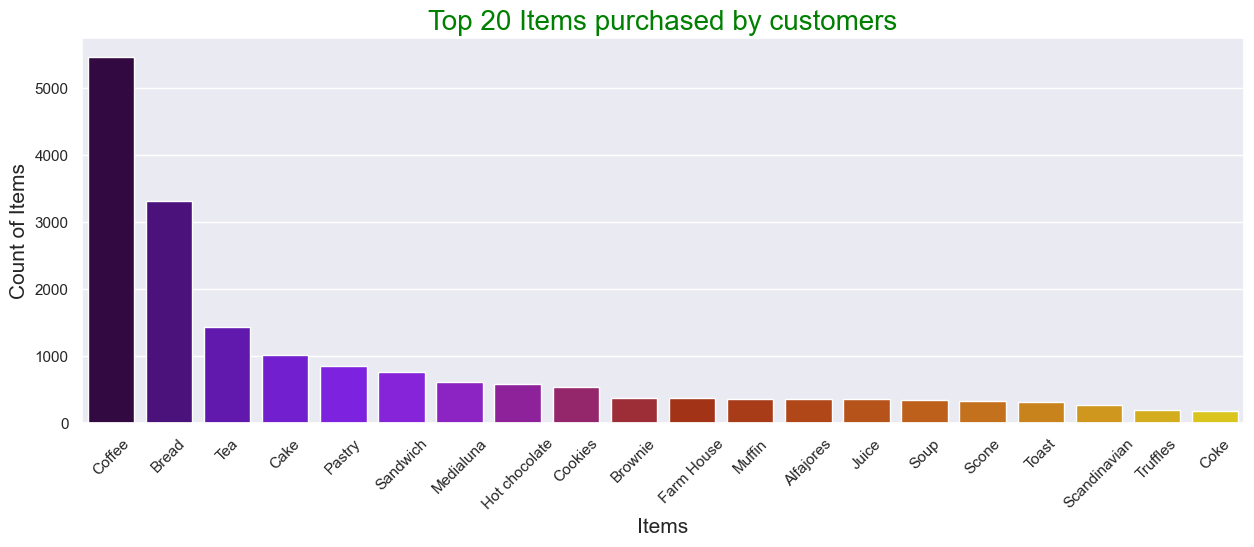

In [407]:
plt.figure(figsize=(15,5))
sns.barplot(x = basket.Item.value_counts().head(20).index, y = basket.Item.value_counts().head(20).values, palette = 'gnuplot')
plt.xlabel('Items', size = 15)
plt.xticks(rotation=45)
plt.ylabel('Count of Items', size = 15)
plt.title('Top 20 Items purchased by customers', color = 'green', size = 20)
plt.show()

Coffee has the highest transactions.

Coke is the 20th most buyed product.

In [408]:
def time_variables(dataframe, colname):
    
    dataframe[colname] = pd.to_datetime(df[colname])
    dataframe['date'] = dataframe[colname].dt.date
    dataframe['time'] = dataframe[colname].dt.time
    dataframe['month'] = dataframe[colname].dt.month
    dataframe['month'] = dataframe['month'].replace([1,2,3,4,5,6,7,8,9,10,11,12],['January','February','March','April','May','June','July','August','September','October','November','December'])
    dataframe['day'] = dataframe[colname].dt.day
    dataframe['weekday'] = dataframe[colname].dt.weekday
    dataframe['weekday'] = dataframe['weekday'].replace([0,1,2,3,4,5,6], ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    
    return dataframe

In [409]:
df = basket.copy()
time_variables(df, 'date_time')
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,date,time,month,day,weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,2016-10-30,09:58:00,October,30,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,2016-10-30,10:05:00,October,30,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,2016-10-30,10:05:00,October,30,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,2016-10-30,10:07:00,October,30,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,2016-10-30,10:07:00,October,30,Sunday
...,...,...,...,...,...,...,...,...,...,...
20502,9682,Coffee,2017-04-09 14:32:00,afternoon,weekend,2017-04-09,14:32:00,April,9,Sunday
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend,2017-04-09,14:32:00,April,9,Sunday
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend,2017-04-09,14:57:00,April,9,Sunday
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend,2017-04-09,14:57:00,April,9,Sunday


,Transaction,Item,date_time,period_day,weekday_weekend,date,time,month,day,weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,2016-10-30,09:58:00,October,30,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,2016-10-30,10:05:00,October,30,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,2016-10-30,10:05:00,October,30,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,2016-10-30,10:07:00,October,30,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,2016-10-30,10:07:00,October,30,Sunday


<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='month', ylabel='Transaction'>

Text(0.5, 0, 'Months')

Text(0, 0.5, 'Orders per month')

Text(0.5, 1.0, 'Number of orders received each month')

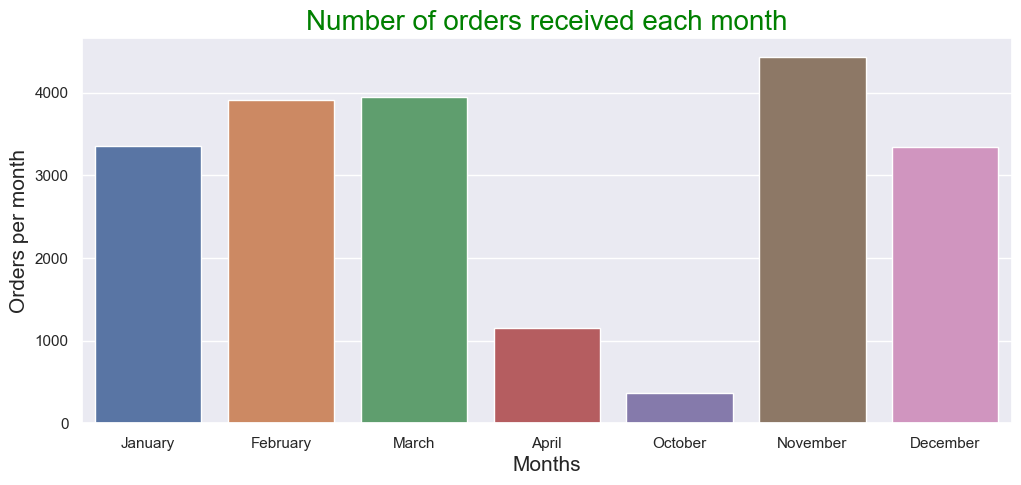

In [410]:
monthTran = df.groupby('month')['Transaction'].count().reset_index()
monthTran.loc[:,"monthorder"] = [4,12,2,1,3,11,10] #[4,8,12,2,1,7,6,3,5,11,10,9]
monthTran.sort_values("monthorder",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = monthTran, x = "month", y = "Transaction")
plt.xlabel('Months', size = 15)
plt.ylabel('Orders per month', size = 15)
plt.title('Number of orders received each month', color = 'green', size = 20)
plt.show()


plt.show()

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='weekday', ylabel='Transaction'>

Text(0.5, 0, 'Week Day')

Text(0, 0.5, 'Orders per day')

Text(0.5, 1.0, 'Number of orders received each day')

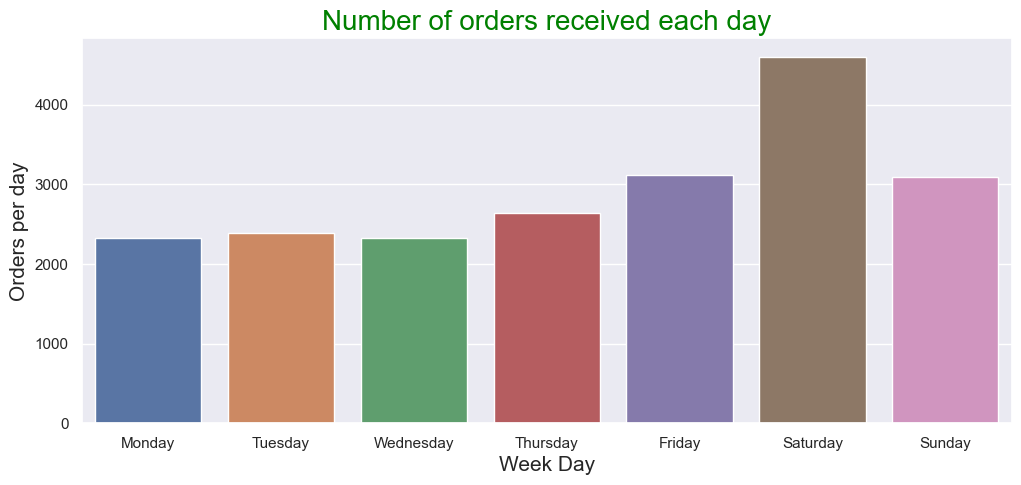

In [411]:
weekTran = df.groupby('weekday')['Transaction'].count().reset_index()
weekTran.loc[:,"weekorder"] = [4,0,5,6,3,1,2]
weekTran.sort_values("weekorder",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = weekTran, x = "weekday", y = "Transaction")
plt.xlabel('Week Day', size = 15)
plt.ylabel('Orders per day', size = 15)
plt.title('Number of orders received each day', color = 'green', size = 20)
plt.show()


plt.show()

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='Transaction', ylabel='period_day'>

Text(0, 0.5, 'Period')

Text(0.5, 0, 'Orders each period of a day')

Text(0.5, 1.0, 'Count of orders received each period of a day')

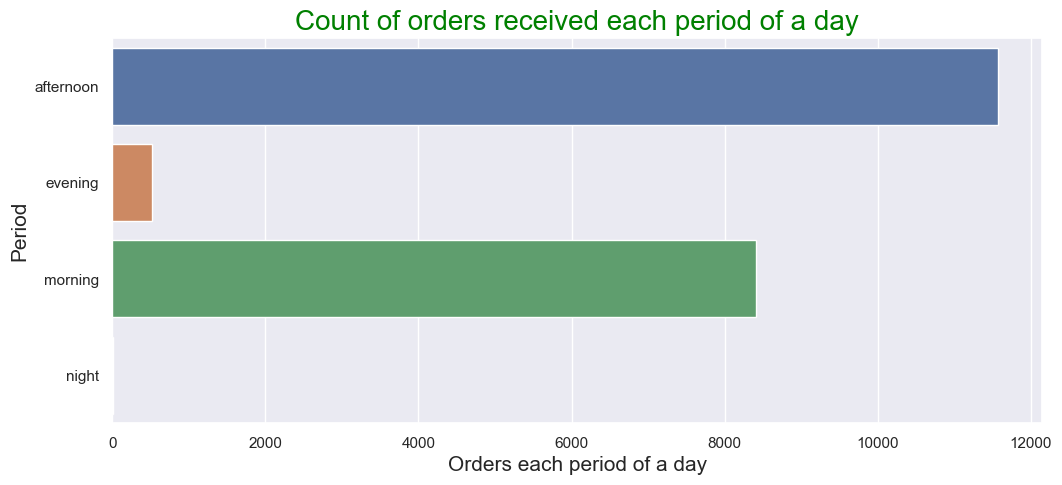

In [412]:
dayTran = df.groupby('period_day')['Transaction'].count().reset_index()
# dayTran.loc[:,"hourorder"] = [1,10,11,12,13,14,15,16,17,18,19,20,21,22,23,7,8,9]
# dayTran.sort_values("hourorder",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = dayTran, x = "Transaction", y = "period_day")
plt.ylabel('Period', size = 15)
plt.xlabel('Orders each period of a day', size = 15)
plt.title('Count of orders received each period of a day', color = 'green', size = 20)
plt.show()

<Figure size 1500x800 with 0 Axes>

<Axes: >

<Axes: xlabel='Transaction', ylabel='Item'>

Text(0.5, 0, '')

Text(0, 0.5, '')

...

<Axes: >

<Axes: xlabel='Transaction', ylabel='Item'>

Text(0.5, 0, '')

Text(0, 0.5, '')

Text(0.5, 1.0, 'Top 10 items people like to order in "night"')

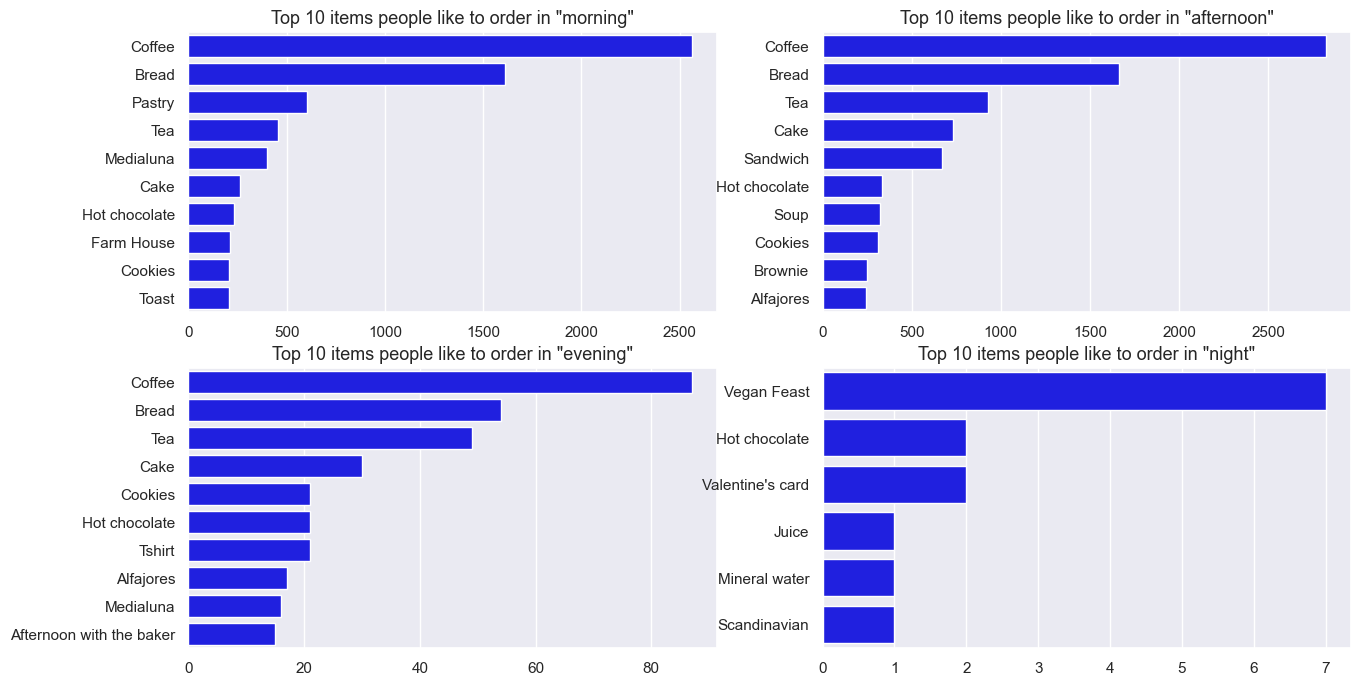

In [413]:
data = df.groupby(['period_day','Item'])['Transaction'].count().reset_index().sort_values(['period_day','Transaction'],ascending=False)
day = ['morning','afternoon','evening','night']

plt.figure(figsize=(15,8))
for i,j in enumerate(day):
    plt.subplot(2,2,i+1)
    df1 = data[data.period_day==j].head(10)
    sns.barplot(data=df1, y=df1.Item, x=df1.Transaction, color='blue')
    plt.xlabel('')
    plt.ylabel('')
    plt.title('Top 10 items people like to order in "{}"'.format(j), size=13)

plt.show()

PLAYTIME: 
<div class="alert alert-success">
PLAYTIME: Which are the conclusions from the exploratory data analysis? which are the best-selling products? what time of the day the bakery is mostly making its sales? and during the days of the week? and the months?</div>

EDA Summary:
<p style="padding-left: 20px; padding-bottom: 20px; color:#4a4a4a; font-size:110%;"> 
<b>Write here your conclusions</b> 
</p>


### Creating Transactions from the dataset

In [414]:
basket.loc[basket['Transaction']==3]

,Transaction,Item,date_time,period_day,weekday_weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
5,3,Cookies,30-10-2016 10:07,morning,weekend


In [415]:
transactions = [a[1]['Item'].tolist() for a in list(basket.groupby(['date_time','period_day','Transaction','weekday_weekend']))]
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
transactions = pd.DataFrame(te_ary, columns=te.columns_)
pf = transactions.describe()
transactions.describe()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
count,9465,9465,9465,9465,9465,9465,9465,9465,9465,9465,...,9465,9465,9465,9465,9465,9465,9465,9465,9465,9465
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
freq,9464,9422,9121,9458,9427,9464,9313,9417,9460,9459,...,9464,9407,9319,9147,9273,9444,9452,9449,9413,9458


In [330]:
f = pf.iloc[0]-pf.iloc[3]
f


Adjustment                    1
Afternoon with the baker     43
Alfajores                   344
Argentina Night               7
Art Tray                     38
                           ... 
Tshirt                       21
Valentine's card             13
Vegan Feast                  16
Vegan mincepie               52
Victorian Sponge              7
Length: 94, dtype: object

In [453]:
f = pf.iloc[0]-pf.iloc[3]
a = f.tolist()
b = list(f.index)
item = pd.DataFrame([[a[r],b[r]]for r in range(len(a))], columns=['Count','Item'])
item = item.sort_values(['Count'], ascending=False).head(30)
item

,Count,Item
23,4528,Coffee
11,3097,Bread
83,1350,Tea
15,983,Cake
65,815,Pastry
73,680,Sandwich
55,585,Medialuna
48,552,Hot chocolate
26,515,Cookies
14,379,Brownie


PLAYTIME
<div class="alert alert-success">
PLAYTIME: Try to understand the following code and the results. How the transactions are represented? What is the support, confidence and lift of the rules? What is the meaning of the rules?
</div>

In [332]:
def encoder(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1
    
apriori_basket_set = transactions.applymap(encoder)
apriori_basket_set

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9460,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9462,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9463,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Exploratory data visualizations

<Axes: >

(0.0, 100.0, 0.0, 100.0)

Text(0.5, 1.0, 'Top 30 Frequent Basket Items')

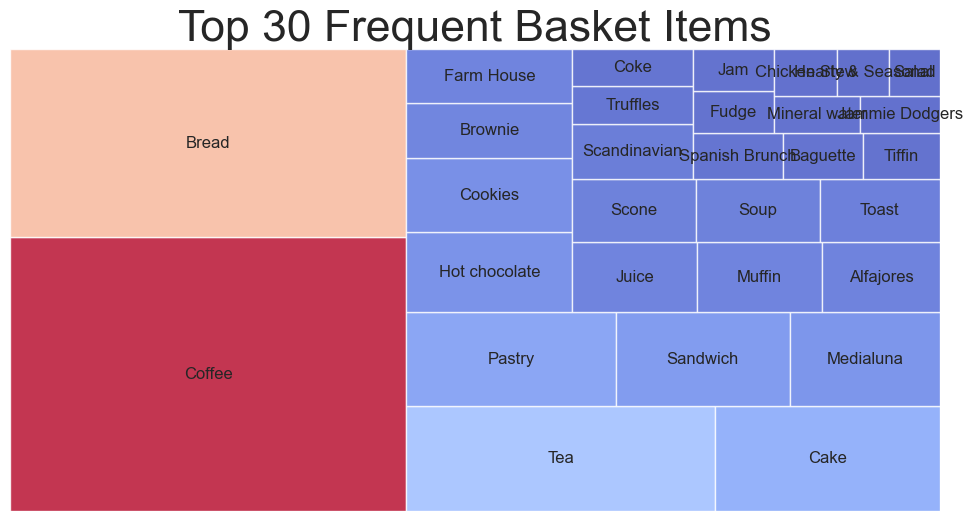

In [417]:
fig, ax = plt.subplots()
cmap = matplotlib.cm.coolwarm

mini = min(item["Count"])
maxi = max(item["Count"])

norm = matplotlib.colors.Normalize(vmin=mini, vmax=maxi)
colors = [cmap(norm(value)) for value in item["Count"]]

squarify.plot(sizes=item["Count"], label=item["Item"], alpha=0.8, color=colors)
plt.axis('off')
plt.title("Top 30 Frequent Basket Items", fontsize=32)
ttl = ax.title
ttl.set_position([.5, 1.05])

(-0.5, 799.5, 399.5, -0.5)

Text(0.5, 1.0, 'Items')

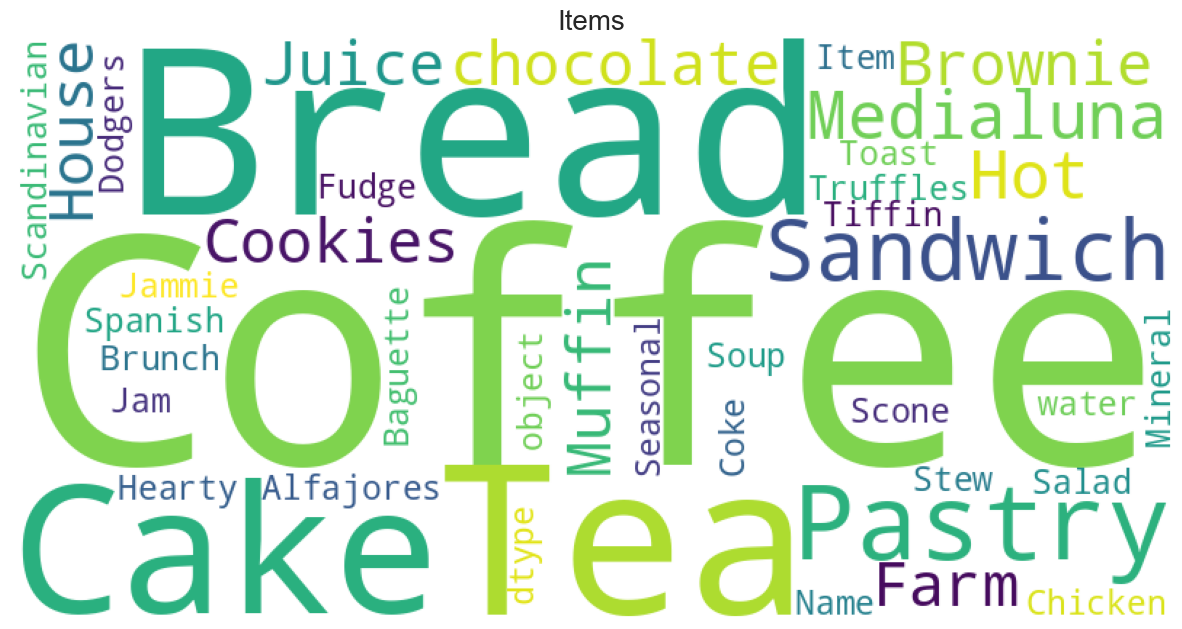

In [473]:
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (15, 15)
wordcloud = WordCloud(background_color = 'white', width = 800,  height = 400, max_words = 121).generate(str(item['Item']))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Items',fontsize = 20)
plt.show()

PLAYTIME:
<div class="alert alert-success">
PLAYTIME: What are the top 4 items that are bought by people? 
</div>

### More on metrics 

Lets consider the rule X => Y in order to compute these metrics.

![](https://s3.ap-south-1.amazonaws.com/techleer/243.jpg)

In [474]:
# Groupby by the Transaction Ids and count items
apriori_data = basket.groupby(
              by=['Transaction', 
                  'Item'])['Item'].count().reset_index(name='Item_Count')

# Pivot table by the transaction and convert item count to boolean 
apriori_basket = apriori_data.pivot_table(
              index='Transaction', 
              columns='Item', 
              values='Item_Count', 
              aggfunc='sum').fillna(0)
apriori_basket

Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9680,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9681,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
9682,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [475]:
def encoder(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1
    
apriori_basket_set = apriori_basket.applymap(encoder)
apriori_basket_set

Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9680,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9681,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9682,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [476]:
# Add antecedent and consequent pairs to the data set 
apriori_basket['Coffee & Bread'] = np.logical_and(apriori_basket['Coffee'], apriori_basket['Bread'])
apriori_basket['Coffee & Tea'] = np.logical_and(apriori_basket['Coffee'], apriori_basket['Tea'])
apriori_basket['Coffee & Cake'] = np.logical_and(apriori_basket['Coffee'], apriori_basket['Cake'])

# Calculate support
support = apriori_basket.mean().sort_values(ascending=False)
support.head(10)

Item
Coffee           0.578
Bread            0.351
Tea              0.152
Cake             0.108
Pastry           0.090
Coffee & Bread   0.090
Sandwich         0.081
Medialuna        0.065
Hot chocolate    0.062
Cookies          0.057
dtype: float64

PLAYTIME:

<div class="alert alert-success">
PLAYTIME: Compute the confidence and lift of the rule (Coffee => Bread) and (Coffe => Cake). What is the meaning of these rules? 
</div>


In [ ]:
# Confidence value of if Coffee then Bread 
#print(##HERE)

# Confidence value of if Coffee then Cake 
#print(##HERE)

0.15573021385487112
0.09468104551270334


In [ ]:
# Lift value of if Coffee then Bread 
#print(##HERE)

# Lift value of if Coffee then Cake 
#print(##HERE)

0.44330420274777604
0.8742986300270608


In [479]:
# Leverage value of if Coffee then Bread 
print(support['Coffee & Bread'] - (support['Coffee']*support['Bread']))

# Leverage value of if Coffee then Cake 
print(support['Coffee & Cake'] - (support['Coffee']*support['Cake']))

-0.1130407604517324
-0.007868452990401141


In [480]:
# Conviction value of if Coffee then Bread 
print(support['Coffee']*(
        1-support['Bread'])/(support['Coffee'] - support['Coffee & Bread']))

# Conviction value of if Coffee then Cake 
print(support['Coffee']*(
        1-support['Cake'])/(support['Coffee'] - support['Coffee & Cake']))

0.7683631094012456
0.9849636770534734


PLAYTIME:

<div class="alert alert-success">
PLAYTIME: Apply Apriori algorithm to the dataset, compute support and lift and generate the association rules. What are the items that have a support of at least 0.01?
</div>

In [ ]:
from mlxtend.frequent_patterns import association_rules, apriori
data = pd.read_csv("./bread_basket.csv")

def encoder(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

apriori_data = data.groupby(['Transaction','Item'])['Item'].count().reset_index(name ='Item_Count')
apriori_basket = apriori_data.pivot_table(index = 'Transaction', columns = 'Item', values = 'Item_Count', aggfunc = 'sum').fillna(0)
#apriori_basket_set = apriori_basket.applymap(encoder)
apriori_basket_set

# Apply Apriori algorithm
# frequent_itemsets = ...

Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9680,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9681,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9682,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
## HERE sort the values by support

,support,itemsets
6,0.478,(Coffee)
2,0.327,(Bread)
26,0.143,(Tea)
4,0.104,(Cake)
34,0.090,"(Coffee, Bread)"
19,0.086,(Pastry)
21,0.072,(Sandwich)
16,0.062,(Medialuna)
12,0.058,(Hot chocolate)
42,0.055,"(Cake, Coffee)"


PLAYTIME:

<div class="alert alert-success">
PLAYTIME: What are the rules that have a lift of at least 0.01? Sort them by confidence.
</div>

In [ ]:
# Compute association rules

# apriori_rules = ...
# apriori_rules.sort_values(# HERE)


In [484]:
#apriori_rules=apriori_rules.rename(columns = {'antecedents':'lhs'})
#apriori_rules=apriori_rules.rename(columns = {'consequents':'rhs'})
apriori_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
52,(Toast),(Coffee),0.034,0.478,0.024,0.704,1.472,0.008,1.765,0.332
49,(Spanish Brunch),(Coffee),0.018,0.478,0.011,0.599,1.252,0.002,1.300,0.205
36,(Medialuna),(Coffee),0.062,0.478,0.035,0.569,1.190,0.006,1.211,0.170
41,(Pastry),(Coffee),0.086,0.478,0.048,0.552,1.154,0.006,1.165,0.146
2,(Alfajores),(Coffee),0.036,0.478,0.020,0.541,1.130,0.002,1.136,0.120
...,...,...,...,...,...,...,...,...,...,...
61,(Bread),"(Cake, Coffee)",0.327,0.055,0.010,0.031,0.560,-0.008,0.975,-0.538
65,(Coffee),"(Pastry, Bread)",0.478,0.029,0.011,0.023,0.803,-0.003,0.994,-0.320
48,(Coffee),(Spanish Brunch),0.478,0.018,0.011,0.023,1.252,0.002,1.005,0.386
60,(Coffee),"(Cake, Bread)",0.478,0.023,0.010,0.021,0.899,-0.001,0.998,-0.178


In [485]:
#Sort the rules 
#rules = rules.sort_values(['lift'], ascending =[False])#From Frozenset to string
#rules["antecedents"] = rules["antecedents"].apply(lambda x: list(x)[0]).astype("unicode")
#rules["consequents"] = rules["consequents"].apply(lambda x: list(x)[0]).astype("unicode")
#Table with most relevant rules
#print(rules.sort_values('lift', ascending=False).nlargest(10, 'lift'))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,lhs_items
70,"(Tea, Coffee)",(Cake),0.050,0.104,0.010,0.201,1.938,0.005,1.122,0.509,2
63,"(Coffee, Bread)",(Pastry),0.090,0.086,0.011,0.124,1.445,0.003,1.044,0.338,2
69,"(Cake, Coffee)",(Tea),0.055,0.143,0.010,0.183,1.286,0.002,1.050,0.235,2
58,"(Coffee, Bread)",(Cake),0.090,0.104,0.010,0.112,1.074,0.001,1.009,0.075,2
57,"(Cake, Bread)",(Coffee),0.023,0.478,0.010,0.430,0.899,-0.001,0.915,-0.104,2


<Axes: xlabel='consequents_', ylabel='antecedents_'>

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0, 0.5, 'Cake,Bread'),
  Text(0, 1.5, 'Cake,Coffee'),
  Text(0, 2.5, 'Cake,Tea'),
  Text(0, 3.5, 'Coffee,Bread'),
  Text(0, 4.5, 'Coffee,Pastry'),
  Text(0, 5.5, 'Pastry,Bread'),
  Text(0, 6.5, 'Tea,Coffee')])

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0.5, 0, 'Bread'),
  Text(1.5, 0, 'Cake'),
  Text(2.5, 0, 'Coffee'),
  Text(3.5, 0, 'Pastry'),
  Text(4.5, 0, 'Tea')])

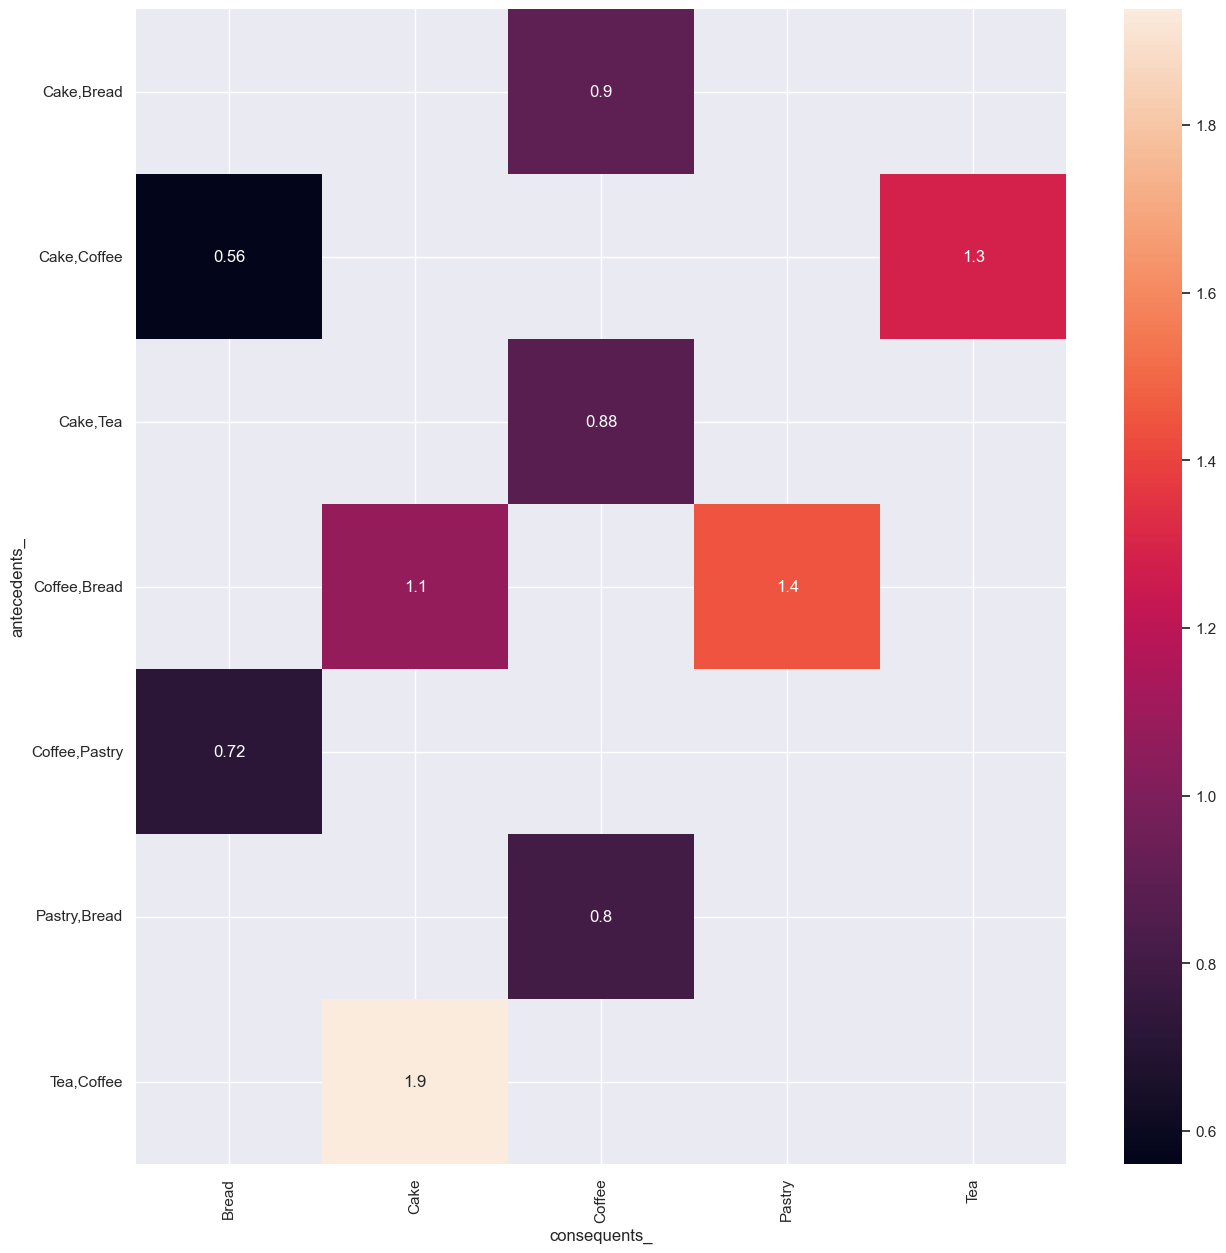

In [486]:
apriori_rules['lhs_items'] = apriori_rules['antecedents'].apply(lambda x:len(x) )
apriori_rules[apriori_rules['lhs_items']>1].sort_values('lift', ascending=False).head()
apriori_rules['antecedents_'] = apriori_rules['antecedents'].apply(lambda a: ','.join(list(a)))
apriori_rules['consequents_'] = apriori_rules['consequents'].apply(lambda a: ','.join(list(a)))
pivot = apriori_rules[apriori_rules['lhs_items']>1].pivot(index = 'antecedents_', columns = 'consequents_', values= 'lift')
sns.heatmap(pivot, annot = True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

PLAYTIME:

<div class="alert alert-success">
PLAYTIME: Can you explain what this heatmap represents? what is the meaning of the rules? 
</div>

In [487]:
apriori_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,lhs_items,antecedents_,consequents_
52,(Toast),(Coffee),0.034,0.478,0.024,0.704,1.472,0.008,1.765,0.332,1,Toast,Coffee
49,(Spanish Brunch),(Coffee),0.018,0.478,0.011,0.599,1.252,0.002,1.300,0.205,1,Spanish Brunch,Coffee
36,(Medialuna),(Coffee),0.062,0.478,0.035,0.569,1.190,0.006,1.211,0.170,1,Medialuna,Coffee
41,(Pastry),(Coffee),0.086,0.478,0.048,0.552,1.154,0.006,1.165,0.146,1,Pastry,Coffee
2,(Alfajores),(Coffee),0.036,0.478,0.020,0.541,1.130,0.002,1.136,0.120,1,Alfajores,Coffee
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,(Bread),"(Cake, Coffee)",0.327,0.055,0.010,0.031,0.560,-0.008,0.975,-0.538,1,Bread,"Cake,Coffee"
65,(Coffee),"(Pastry, Bread)",0.478,0.029,0.011,0.023,0.803,-0.003,0.994,-0.320,1,Coffee,"Pastry,Bread"
48,(Coffee),(Spanish Brunch),0.478,0.018,0.011,0.023,1.252,0.002,1.005,0.386,1,Coffee,Spanish Brunch
60,(Coffee),"(Cake, Bread)",0.478,0.023,0.010,0.021,0.899,-0.001,0.998,-0.178,1,Coffee,"Cake,Bread"


In [488]:
data = pd.read_csv("./bread_basket.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


{'Bakery': Text(-0.0016513185292917325, 0.00338051382682408, 'Bakery'),
 'Coffee': Text(0.4203913010903749, 0.5538705926957715, 'Coffee'),
 'Bread': Text(0.46612310072083274, 0.8571632812371621, 'Bread'),
 'Tea': Text(-0.6001343562632591, -0.7690578295512026, 'Tea'),
 'Cake': Text(-0.7947066668143675, -0.5295299326804511, 'Cake'),
 'Sandwich': Text(-0.41138707979190053, -0.516182849462071, 'Sandwich'),
 'Pastry': Text(0.8802517804412018, 0.3650255725401443, 'Pastry'),
 'Cookies': Text(1.0, 0.06274688891540908, 'Cookies'),
 'Hot chocolate': Text(-0.5894237970185661, -0.18732463922558265, 'Hot chocolate'),
 'Medialuna': Text(-0.5806989884736867, 0.5775096633218583, 'Medialuna'),
 'Juice': Text(0.273386451111012, -0.9088894098155894, 'Juice'),
 'Scone': Text(-0.4807803129355355, 0.2044968509301108, 'Scone'),
 'Toast': Text(-0.4855910740514371, 0.8676856261367651, 'Toast'),
 'Soup': Text(0.7132565120073658, -0.5713483852674486, 'Soup'),
 'Brownie': Text(0.5595890602058317, 0.23323325314760

(-1.1855144445011054,
 1.2076733182557613,
 -1.1541854484815168,
 1.1503024830515853)

Text(0.5, 1.0, 'Top 30 Products at The Bread Basket Bakery')

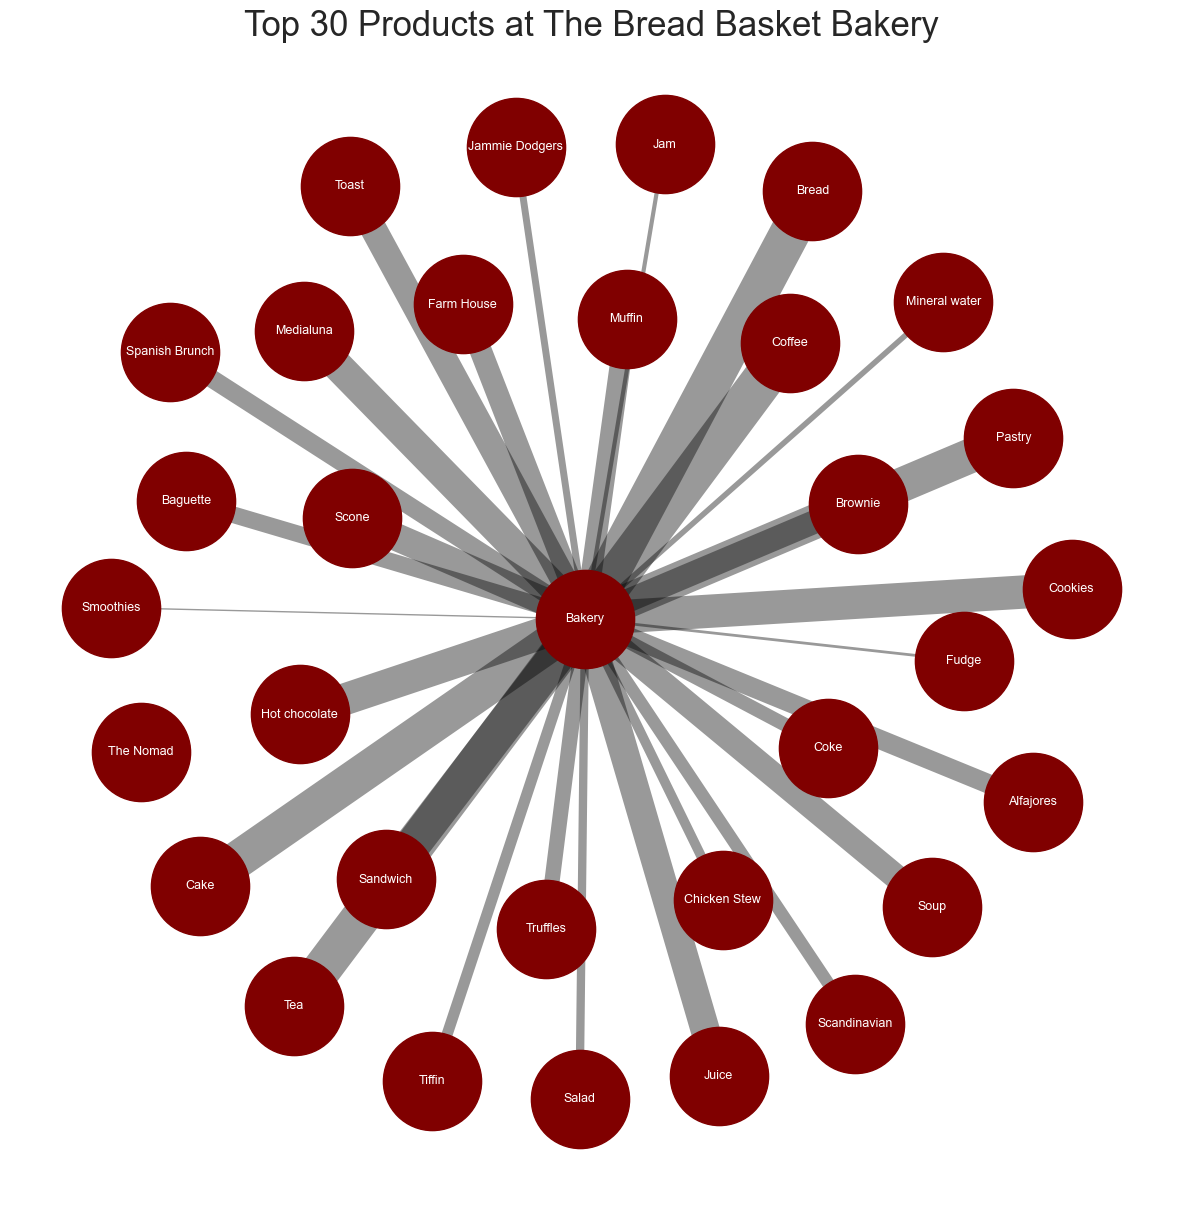

In [489]:
data_vis = data.copy()
df_network_first = data_vis.groupby("Item").sum().sort_values("Transaction", ascending=False).reset_index()
df_network_first["Type"] = "Bakery"
df_network_first = df_network_first.truncate(before=-1, after=30) # top 30
plt.rcParams['figure.figsize']=(15,15)
j = 0
for i, _ in reversed(list(enumerate(df_network_first['Transaction']))):
    df_network_first['Transaction'][j] = i
    j+=1
first_choice = nx.from_pandas_edgelist(df_network_first, source='Type', target="Item", edge_attr='Transaction')
prior = [i['Transaction'] for i in dict(first_choice.edges).values()]
pos = nx.spring_layout(first_choice)
nx.draw_networkx_nodes(first_choice, pos, node_size=5000, node_color="maroon")
nx.draw_networkx_edges(first_choice, pos, width=prior, alpha=0.4, edge_color='black')
nx.draw_networkx_labels(first_choice, pos, font_size=9, font_family='sans-serif', font_color = 'white')
plt.axis('off')
plt.grid()
plt.title('Top 30 Products at The Bread Basket Bakery', fontsize=25)
plt.show()

### Parallel category plots

Parallel categories diagram is a visualization of multi-dimensional categorical datasets wherein each variable in the dataset is represented by a column of rectangles, where each rectangle corresponds to a discrete value taken on by that variable.

https://plotly.com/python/parallel-categories-diagram/#:~:text=The%20parallel%20categories%20diagram%20



In [490]:
import PyARMViz as viz
from PyARMViz.Rule import Rule

apriori_vis = apriori_rules

apriori_vis['uni'] = np.nan
apriori_vis['ant'] = np.nan
apriori_vis['con'] = np.nan
apriori_vis['tot'] = 20507

transactions = [a[1]['Item'].tolist() for a in list(data.groupby(['Transaction', 'date_time']))]

def tran():
    for t in transactions:
        yield t
def antec(x):
    cnt = 0
    for t in tran():
        t = set(t)
        if x.intersection(t) == x:
            cnt = cnt + 1
    return cnt
vis = apriori_vis.values.tolist()

rules_dict = []
for i in vis:
    i[10] = antec(i[0])
    i[11] = antec(i[1])
    i[9] = antec(i[0].union(i[1]))
    diction = {
        'lhs': tuple(i[0]), 
        'rhs': tuple(i[1]),
        'count_full': i[9],
        'count_lhs': i[10],
        'count_rhs': i[11],
        'lift': i[6],
        'num_transactions': i[13]
    }
    print(diction)
    rules_dict.append(diction)

    

{'lhs': ('Toast',), 'rhs': ('Coffee',), 'count_full': 224, 'count_lhs': 318, 'count_rhs': 4528, 'lift': 1.4724314954330286, 'num_transactions': nan}
{'lhs': ('Spanish Brunch',), 'rhs': ('Coffee',), 'count_full': 103, 'count_lhs': 172, 'count_rhs': 4528, 'lift': 1.2517655004519679, 'num_transactions': nan}
{'lhs': ('Medialuna',), 'rhs': ('Coffee',), 'count_full': 333, 'count_lhs': 585, 'count_rhs': 4528, 'lift': 1.1898783636857841, 'num_transactions': nan}
{'lhs': ('Pastry',), 'rhs': ('Coffee',), 'count_full': 450, 'count_lhs': 815, 'count_rhs': 4528, 'lift': 1.154168202215526, 'num_transactions': nan}
{'lhs': ('Alfajores',), 'rhs': ('Coffee',), 'count_full': 186, 'count_lhs': 344, 'count_rhs': 4528, 'lift': 1.1302348693401265, 'num_transactions': nan}
{'lhs': ('Juice',), 'rhs': ('Coffee',), 'count_full': 195, 'count_lhs': 365, 'count_rhs': 4528, 'lift': 1.11674996369621, 'num_transactions': nan}
{'lhs': ('Sandwich',), 'rhs': ('Coffee',), 'count_full': 362, 'count_lhs': 680, 'count_rhs'

In [491]:
import PyARMViz.Rule as ru
"""
def lift(self):
        
        #The lift of a rule is the ratio of the observed support to the expected
        #support if the lhs and rhs were independent.If X -> Y, then the lift is
        #given by the fraction P(X and Y) / (P(X) * P(Y)).
        
        try:
            observed_support = self.count_full / self.num_transactions
            prod_counts = self.count_lhs * self.count_rhs
            expected_support = prod_counts / self.num_transactions ** 2
            return observed_support / expected_support
        except ZeroDivisionError:
            return None
        except AttributeError:
            return None
"""

rules = []
for rd in rules_dict:
    rule = ru.generate_rule_from_dict(rd)
    #rule
    rules.append(rule)
  
viz.adjacency_parallel_category_plot(rules)


'\ndef lift(self):\n        \n        #The lift of a rule is the ratio of the observed support to the expected\n        #support if the lhs and rhs were independent.If X -> Y, then the lift is\n        #given by the fraction P(X and Y) / (P(X) * P(Y)).\n        \n        try:\n            observed_support = self.count_full / self.num_transactions\n            prod_counts = self.count_lhs * self.count_rhs\n            expected_support = prod_counts / self.num_transactions ** 2\n            return observed_support / expected_support\n        except ZeroDivisionError:\n            return None\n        except AttributeError:\n            return None\n'

In [492]:
f_items = apriori(apriori_basket_set, min_support = 0.01, use_colnames = True)
apriori_rules = association_rules(f_items, metric = 'lift', min_threshold = 0.9)
apriori_rules.sort_values('confidence', ascending = False, inplace = True)
apriori_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
32,(Toast),(Coffee),0.034,0.478,0.024,0.704,1.472,0.008,1.765,0.332
31,(Spanish Brunch),(Coffee),0.018,0.478,0.011,0.599,1.252,0.002,1.300,0.205
18,(Medialuna),(Coffee),0.062,0.478,0.035,0.569,1.190,0.006,1.211,0.170
23,(Pastry),(Coffee),0.086,0.478,0.048,0.552,1.154,0.006,1.165,0.146
0,(Alfajores),(Coffee),0.036,0.478,0.020,0.541,1.130,0.002,1.136,0.120
16,(Juice),(Coffee),0.039,0.478,0.021,0.534,1.117,0.002,1.120,0.109
25,(Sandwich),(Coffee),0.072,0.478,0.038,0.532,1.113,0.004,1.115,0.109
6,(Cake),(Coffee),0.104,0.478,0.055,0.527,1.102,0.005,1.103,0.103
27,(Scone),(Coffee),0.035,0.478,0.018,0.523,1.093,0.002,1.093,0.088
13,(Cookies),(Coffee),0.054,0.478,0.028,0.518,1.084,0.002,1.083,0.082


### Support vs Confidence vs Lift

In [439]:
fig=px.scatter(apriori_rules['support'], apriori_rules['confidence'])
fig.update_layout(
    xaxis_title="support",
    yaxis_title="confidence",
   
    font_family="Courier New",
    font_color="blue",
    title_font_family="Times New Roman",
    title_font_color="red",
    title=('Support vs Confidence')
    
)

#fig.show()

In [440]:
fig=px.scatter(apriori_rules['support'], apriori_rules['lift'])
fig.update_layout(
    xaxis_title="support",
    yaxis_title="lift",
   
    font_family="Courier New",
    font_color="blue",
    title_font_family="Times New Roman",
    title_font_color="red",
    title=('Support vs Lift')
    
)

#fig.show()

Text(0.5, 0, 'Lift')

Text(0, 0.5, 'Confidence')

Text(0.5, 1.0, 'Confidence vs Lift')

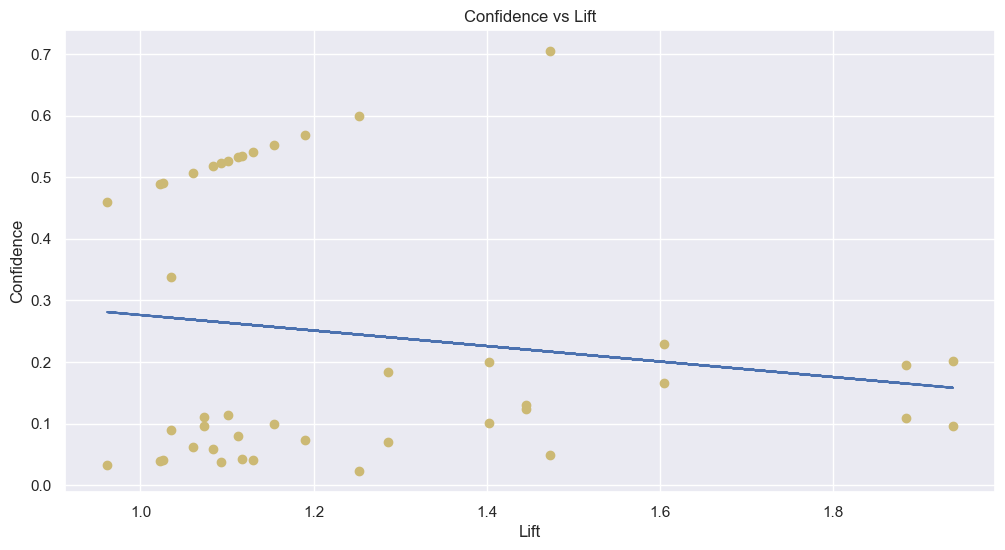

In [441]:
matplotlib.rcParams['figure.figsize'] = (12, 6)
fit = np.polyfit(apriori_rules['lift'], apriori_rules['confidence'], 1)
fit_fn = np.poly1d(fit)
plt.plot(apriori_rules['lift'], apriori_rules['confidence'], 'yo', apriori_rules['lift'], 
fit_fn(apriori_rules['lift']))
plt.xlabel('Lift')
plt.ylabel('Confidence')
plt.title('Confidence vs Lift')

PLAYTIME: <div class="alert alert-success">
**PLAYTIME**: Check the code above. What the blue line stands for? 
</div>

In [442]:
import PyARMViz as viz
from PyARMViz.Rule import Rule

apriori_vis = apriori_rules

apriori_vis['uni'] = np.nan
apriori_vis['ant'] = np.nan
apriori_vis['con'] = np.nan
apriori_vis['tot'] = 20507

transactions = [a[1]['Item'].tolist() for a in list(data.groupby(['Transaction', 'date_time']))]

def tran():
    for t in transactions:
        yield t
def antec(x):
    cnt = 0
    for t in tran():
        t = set(t)
        if x.intersection(t) == x:
            cnt = cnt + 1
    return cnt
vis = apriori_vis.values.tolist()

rules_dict = []
for i in vis:
    i[10] = antec(i[0])
    i[11] = antec(i[1])
    i[9] = antec(i[0].union(i[1]))
    diction = {
        'lhs': tuple(i[0]), 
        'rhs': tuple(i[1]),
        'count_full': i[9],
        'count_lhs': i[10],
        'count_rhs': i[11],
        'num_transactions': i[13]
    }
    rules_dict.append(diction)

    

In [ ]:
vis

In [443]:
rules = []
for rd in rules_dict:
    rules.append(ru.generate_rule_from_dict(rd))
viz.adjacency_parallel_category_plot(rules)

### Association rule strength 

Association rule strength is a scatterplot with support and confidence on its axes, in addition to the third measure which is lift by default indicated by the color scale. 

In [494]:
viz.adjacency_scatter_plot(rules)

In [446]:
viz.metadata_scatter_plot(rules)

PLAYTIME:
<div class="alert alert-success">
PLAYTIME: Play with the support and lift values to see how the rules changes. Which values of support and lift makes sense for this dataset? Which is the number of rules generated?
</div>

From the plot above, it is clear that rules with high lift have a relatively low support. In fact, in the original paper by Bayardo Jr and Agarwal [1], they depict how the most interesting rules exist on the border of support/confidence. The interactive features of the library helps these rules stand out from a large base of rules.

[1] Bayardo, Jr RJ, Agrawal R (1999). “Mining the most interesting rules.” In KDD ’99: Proceedings of the fifth ACM SIGKDD international conference on Knowledge discovery and data mining, pp. 145–154. ACM

### Refining Rules

The confidence for a very frequent consequent is always high even if there is a very weak association. So this doesn't give a clearer picture. Here, coffee is by far the most frequent item and the best seller. It can therefore be recommended anyway with every other item. So, we can drop the rules recommending coffee to get a clearer picture of the real unknown rules generated from the data.

In [495]:
f_items = apriori(apriori_basket_set, min_support = 0.02, use_colnames = True)
apriori_rules = association_rules(f_items, metric = 'lift', min_threshold = 1)
apriori_rules.antecedents = apriori_rules.antecedents.apply(lambda x: next(iter(x)))
apriori_rules.consequents = apriori_rules.consequents.apply(lambda x: next(iter(x)))
#apriori_rules.sort_values('confidence', ascending = False, inplace = True)
apriori_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,Pastry,Bread,0.086,0.327,0.029,0.339,1.035,0.001,1.017,0.037
1,Bread,Pastry,0.327,0.086,0.029,0.089,1.035,0.001,1.003,0.050
2,Cake,Coffee,0.104,0.478,0.055,0.527,1.102,0.005,1.103,0.103
3,Coffee,Cake,0.478,0.104,0.055,0.114,1.102,0.005,1.012,0.177
4,Cake,Tea,0.104,0.143,0.024,0.229,1.605,0.009,1.112,0.421
5,Tea,Cake,0.143,0.104,0.024,0.167,1.605,0.009,1.075,0.440
6,Coffee,Cookies,0.478,0.054,0.028,0.059,1.084,0.002,1.005,0.148
7,Cookies,Coffee,0.054,0.478,0.028,0.518,1.084,0.002,1.083,0.082
8,Hot chocolate,Coffee,0.058,0.478,0.030,0.507,1.060,0.002,1.059,0.060
9,Coffee,Hot chocolate,0.478,0.058,0.030,0.062,1.060,0.002,1.004,0.109


In [496]:
index_names = apriori_rules[apriori_rules['consequents'] == 'Coffee'].index
refinedRules = apriori_rules.drop(index_names).sort_values('lift', ascending=False)
refinedRules.drop(['leverage','conviction','zhangs_metric'], axis=1, inplace=True)
refinedRules = refinedRules.reset_index()
refinedRules

,index,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,5,Tea,Cake,0.143,0.104,0.024,0.167,1.605
1,4,Cake,Tea,0.104,0.143,0.024,0.229,1.605
2,19,Coffee,Toast,0.478,0.034,0.024,0.049,1.472
3,13,Coffee,Medialuna,0.478,0.062,0.035,0.074,1.190
4,14,Coffee,Pastry,0.478,0.086,0.048,0.099,1.154
5,11,Coffee,Juice,0.478,0.039,0.021,0.043,1.117
6,16,Coffee,Sandwich,0.478,0.072,0.038,0.080,1.113
7,3,Coffee,Cake,0.478,0.104,0.055,0.114,1.102
8,6,Coffee,Cookies,0.478,0.054,0.028,0.059,1.084
9,9,Coffee,Hot chocolate,0.478,0.058,0.030,0.062,1.060


### Summary

PLAYTIME: <div class="alert alert-success">
**PLAYTIME**: Write your insights about the bakery and associations rules found between items. How removing the most frequent item (coffee) affects on checking the rules? is it easier now? What strategies do you recommend to the bakery?
</div>

## Groceries Dataset

PLAYTIME: <div class="alert alert-success">
**PLAYTIME**: Analyse the Groceries dataset and find the most frequent itemsets and association rules.
</div>

In [370]:
basket = pd.read_csv('./Groceries_dataset.csv')
basket

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice
